# Plots to differentiate models

Conda environment for this notebook: `conda env create`


## Plots of training sequences


In [1]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib
import pandas as pd
import numpy as np
%matplotlib inline


# standardize colors
from cycler import cycler 
colors = [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a",]
plt.rcParams['axes.prop_cycle'] = cycler('color', colors)


# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

In [2]:
nrows, ncols = 1, 2

config = [
    {"labelname": "AdaptiveHP", "filepath": "../jettag-hgq2/Training_AdaptiveHP/jettag-hgq2_Training_AdaptiveHP_log.csv"},
    {"labelname": "FixedHP", "filepath": "../jettag-hgq2/Training_FixedHP/jettag-hgq2_Training_FixedHP_log.csv"},
]

data = [
    {
        "labelname": line["labelname"],
        "dataframe": pd.read_csv(line['filepath'], sep=';', index_col=0),
    }
    for line in config
]

data[0]
#df = data[1]["dataframe"]
#df[:10]

{'labelname': 'AdaptiveHP',
 'dataframe':        accuracy      beta   ebops  learning_rate      loss  val_accuracy  \
 epoch                                                                      
 0      0.477858  0.000001  204820       0.005000  1.480795      0.531036   
 1      0.594294  0.000001  204820       0.005000  1.272233      0.614193   
 2      0.634874  0.000001  197268       0.005000  1.174195      0.665151   
 3      0.676117  0.000001  209556       0.005000  1.112969      0.699458   
 4      0.688030  0.000001  209544       0.004999  1.102805      0.656187   
 ...         ...       ...     ...            ...       ...           ...   
 4995   0.199476  0.000993      10       0.000010  1.656598      0.201657   
 4996   0.201127  0.000994      10       0.000010  1.654107      0.201657   
 4997   0.200548  0.000996       9       0.000010  1.654416      0.201657   
 4998   0.201355  0.000997      10       0.000010  1.654132      0.201657   
 4999   0.200663  0.000999       9 

### Accuracy over Ebops

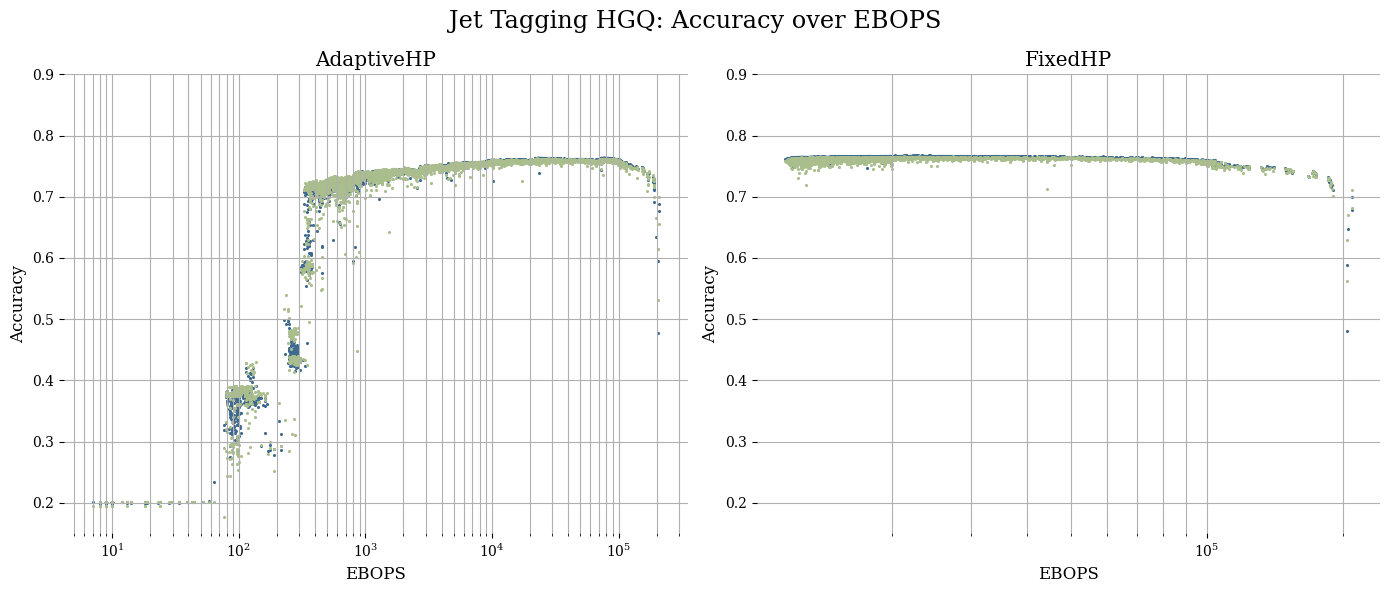

In [3]:
plotname = "Jet Tagging HGQ: Accuracy over EBOPS"
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,figsize=(14, 6))
axs = axs.flatten()

for i, item in enumerate(data):
    #ax = axs[i // 3, i % 3] # flattened instead
    ax1 = axs[i]
    df = item['dataframe']

    ax1.scatter('ebops', 'accuracy', data=df, color=colors[0], s=1.5)#, alpha=0.5)
    ax1.scatter('ebops', 'val_accuracy', data=df, color=colors[1], s=1.5) # val_acc under training does not reflect the test-accuracy after calibration
    ax1.set_xscale("log")
    #ax1.set_xlim(50)

    #ax1.semilogx('ebops', 'accuracy', data=df)
    #ax1.plot('ebops', 'accuracy', data=df, color=colors[0])
    #ax1.set_xlim(0,1000)
    
    ax1.set_ylim(0.15, 0.9) # tilpasset data
    ax1.grid(True, which='both')

    ax1.set_title(item['labelname'],size='x-large')
    ax1.set_xlabel('EBOPS', size='large')
    ax1.set_ylabel('Accuracy', size='large')

    for spine in ("right", "top",
                "left", "bottom"
                ):
        ax1.spines[spine].set_visible(False)

    # Overflow
    if (i+1) > len(data):
        axs[i+1].axis('off')


plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight") #so many dots lol
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")


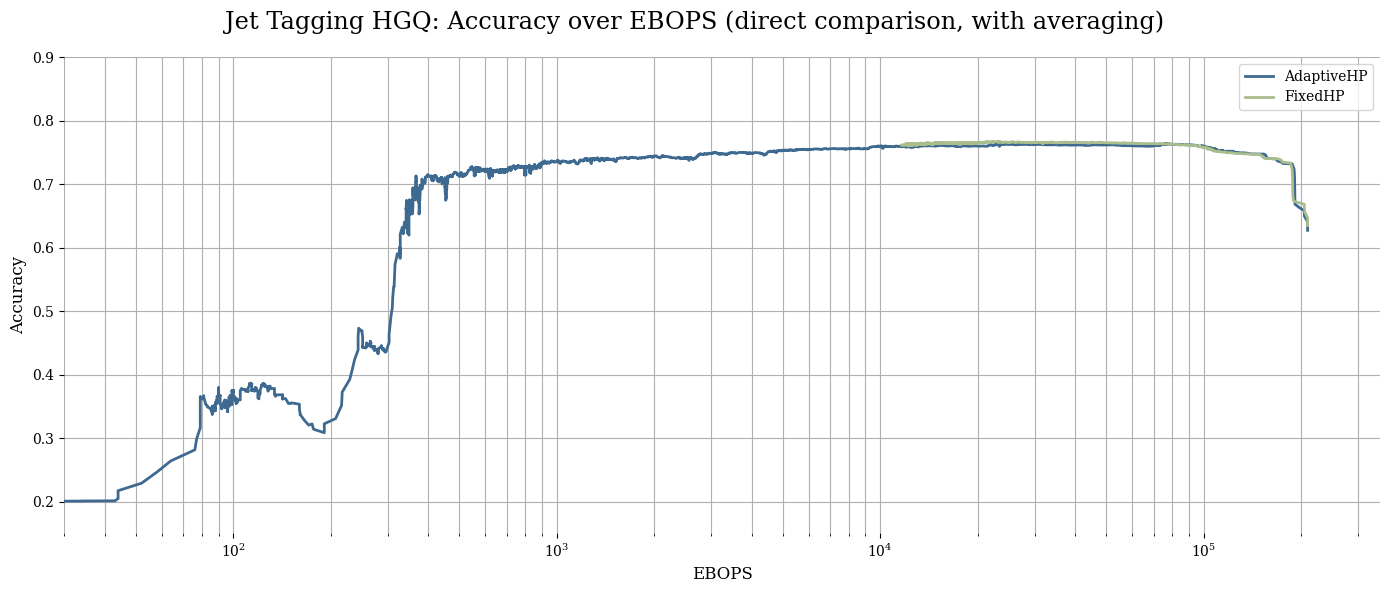

In [4]:
plotname = "Jet Tagging HGQ: Accuracy over EBOPS (direct comparison, with averaging)"
fig, ax = plt.subplots(figsize=(14, 6))

# moving average filter / lavpassfilter for smoothing the colossal amount of data
window_size = 10

for i, item in enumerate(data):
    df = item['dataframe'].sort_values('ebops')
    df_smooth = df.copy()
    df_smooth['accuracy'] = df['accuracy'].rolling(window=window_size, center=True, min_periods=1).mean()
    ax.semilogx('ebops', 'accuracy', data=df_smooth, color=colors[i], label=item['labelname'], linewidth=2)

ax.set_ylim(0.15, 0.9) # tilpasset data
ax.set_xlim(30)
ax.set_xlabel('EBOPS', size='large')
ax.set_ylabel('Accuracy', size='large')
ax.grid(True, which='both')#, axis='x')
ax.legend(loc='best')

for spine in ("right", "top",
                "left", "bottom"
                ):
    ax.spines[spine].set_visible(False)

plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
#plt.title("(direct comparison with averaging)")
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")

### Accuracy and EBOPS over Epochs (timeseries)

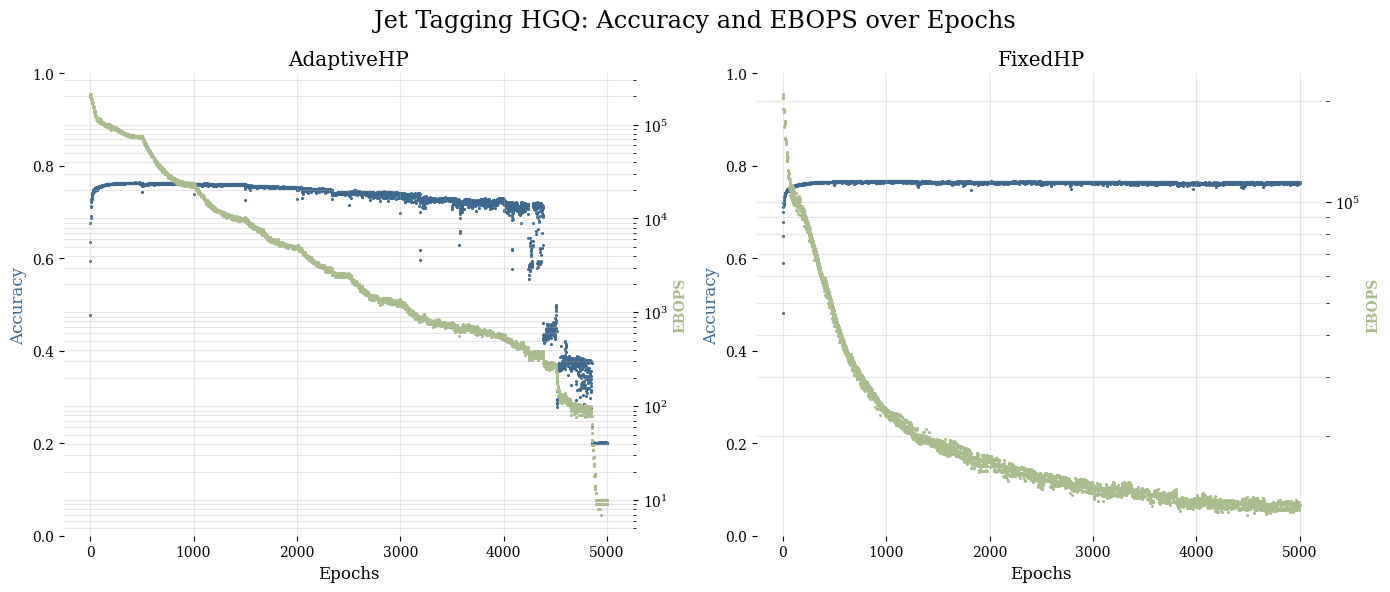

In [5]:
plotname = "Jet Tagging HGQ: Accuracy and EBOPS over Epochs"
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,figsize=(14, 6))
axs = axs.flatten()


for i, item in enumerate(data):
    ax1 = axs[i]
    ax2 = ax1.twinx()
    df = item['dataframe']

    #ax1.plot(df.index, 'accuracy', data=df, color=colors[0])
    ax1.scatter(df.index, 'accuracy', data=df, color=colors[0], s=1.5)
    ax1.set_ylim(0, 1)

    #ax2.semilogy(df.index, 'ebops', data=df, color=colors[1])
    ax2.scatter(df.index, 'ebops', data=df, color=colors[1], s=1.5)
    ax2.set_yscale("log")

    ax1.set_title(item['labelname'],size='x-large')
    ax1.set_xlabel('Epochs', size='large')
    ax1.set_ylabel('Accuracy', color=colors[0], size='large')
    ax2.set_ylabel('EBOPS', color=colors[1], weight='bold')
    ax1.grid(True, which='both', alpha=0.3, axis='x')
    ax2.grid(True, which='both', alpha=0.3)
    for spine in ("right", "top",
                  "left", "bottom"
                  ):
        ax1.spines[spine].set_visible(False)
        ax2.spines[spine].set_visible(False)
    #ax2.grid()
    # Overflow
    if (i+1) > len(data):
        axs[i+1].axis('off')

    
plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")

# Annotations https://matplotlib.org/stable/gallery/text_labels_and_annotations/annotate_transform.html
# Minimalistic https://practicaldatascience.org/notebooks/class_5/week_1/2.2.2_making_plots_pretty_2.html